In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt, patches
from pathlib import Path
import random

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, random_split 

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger

import segmentation_models_pytorch as smp

from utils import (
    IterableOCT5kDataset, 
    OCT5kDataset, 
    LitSegmentation,
    GLOBAL_CONFIG,
)
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from core_utils import stringify_map, get_normal_statistics

In [ ]:
dataset = OCT5kDataset.from_path()

['AMD', 'DME', 'Normal']

In [ ]:
train_img_paths, test_img_paths, train_mask_paths, test_mask_paths, train_targets, test_targets = train_test_split(
    dataset.img_paths, 
    dataset.mask_paths,
    dataset.targets,
    stratify=dataset.targets, 
    test_size=10, 
    random_state=42
)
train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    train_img_paths, 
    train_mask_paths,
    stratify=train_targets, 
    test_size=0.2, 
    random_state=42
)

1672

In [ ]:
train_dataset = OCT5kDataset(train_img_paths, train_mask_paths)
val_dataset = OCT5kDataset(val_img_paths, val_mask_paths)
test_dataset = OCT5kDataset(test_img_paths, test_mask_paths)
del dataset

In [ ]:
OCT5kDataset.classes()

In [ ]:
get_normal_statistics(IterableOCT5kDataset(train_dataset))

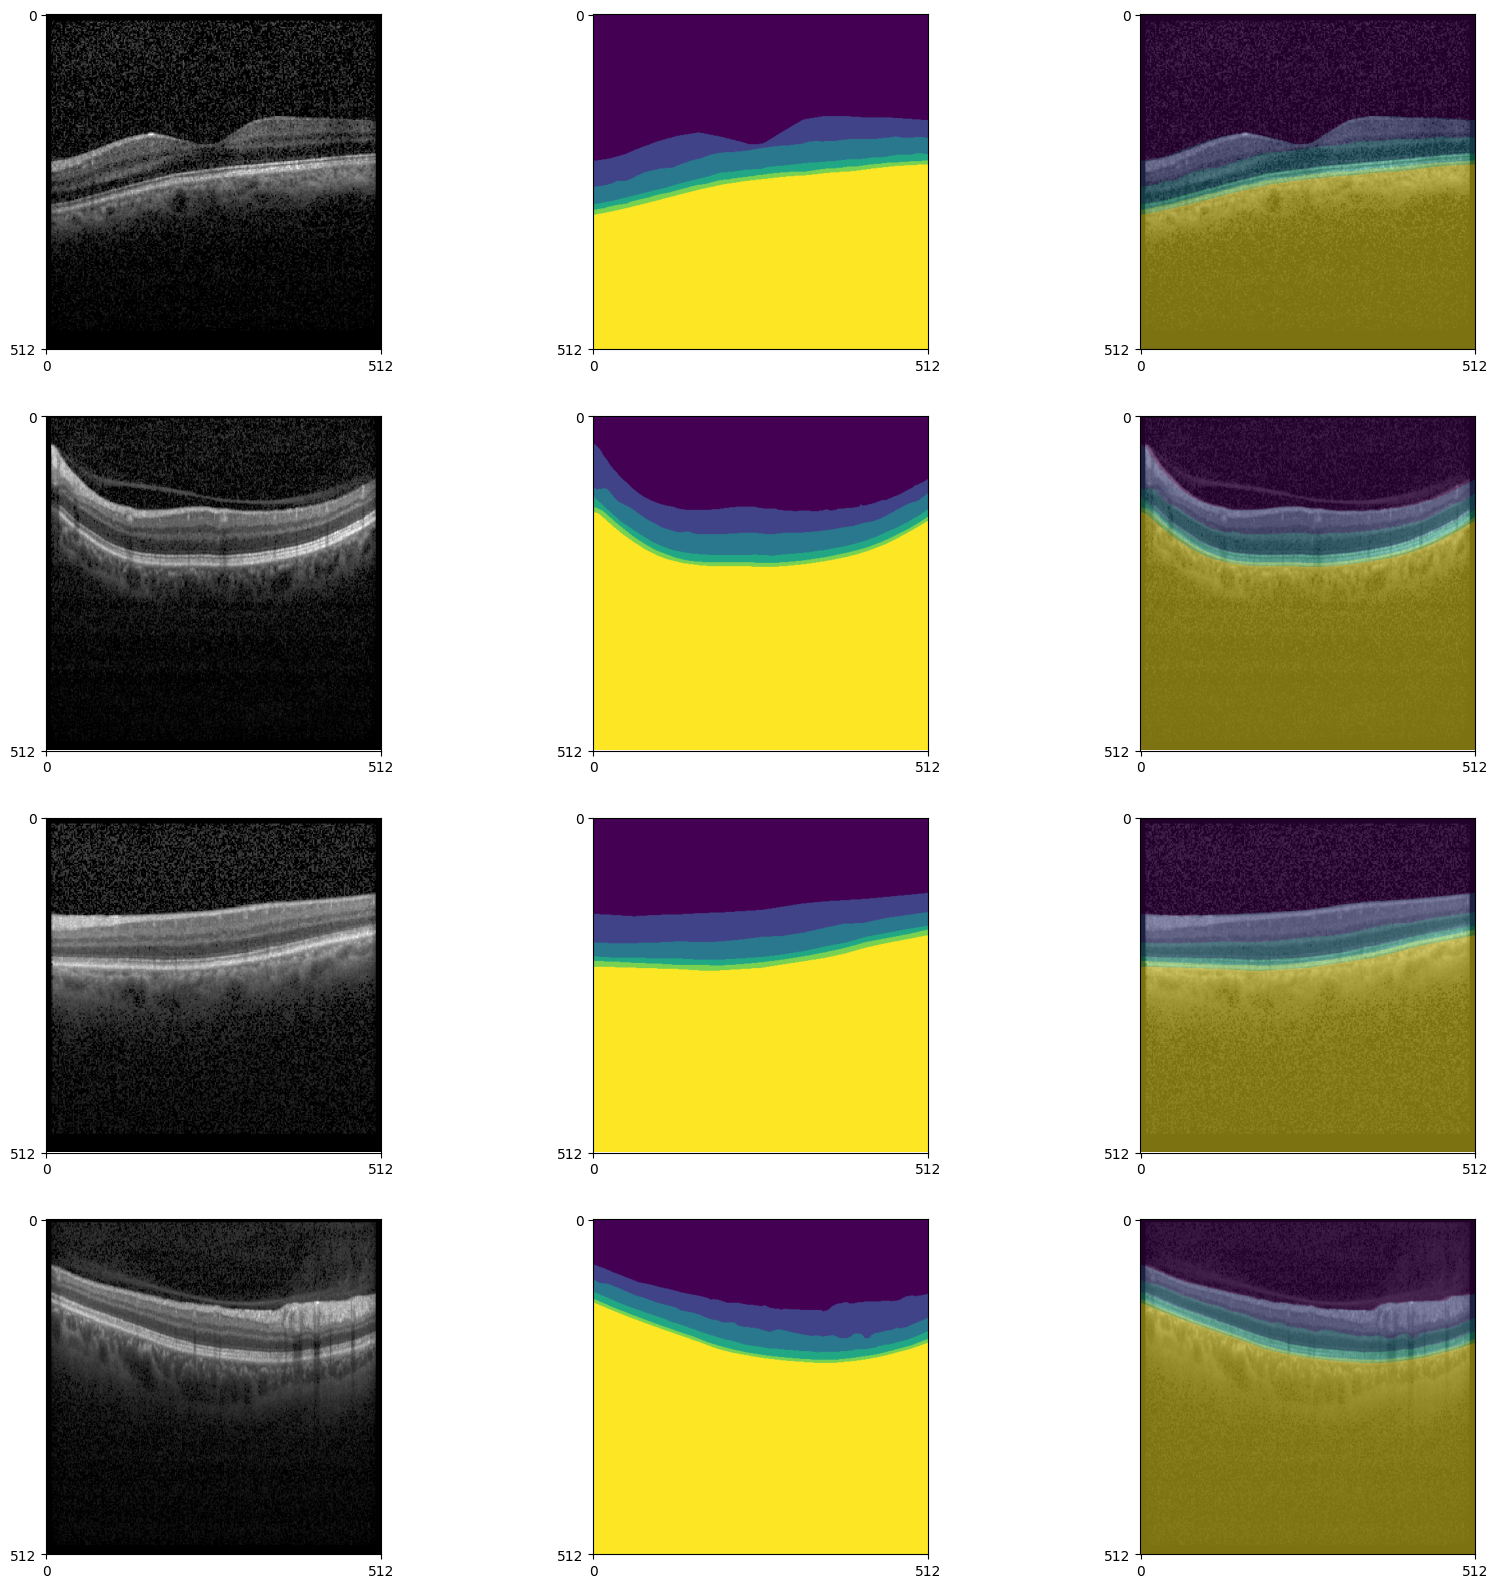

In [5]:
def plot_image_and_label(image, label, ax, title=None):
    img_permuted = image.permute(1, 2, 0)
    lbl_permuted = label.permute(1, 2, 0)
    ax[0].imshow(img_permuted)
    ax[0].set_xticks([0, img_permuted.shape[1]])
    ax[0].set_yticks([0, img_permuted.shape[0]])
    if isinstance(title, str):
        ax[0].set_title(title)

    ax[1].imshow(lbl_permuted, cmap ='viridis')
    ax[1].set_xticks([0, lbl_permuted.shape[1]])
    ax[1].set_yticks([0, lbl_permuted.shape[0]])

    ax[2].imshow(img_permuted)
    ax[2].set_xticks([0, img_permuted.shape[1]])
    ax[2].set_yticks([0, img_permuted.shape[0]])

    ax[2].imshow(lbl_permuted, cmap ='viridis', alpha=0.5)
    ax[2].set_xticks([0, lbl_permuted.shape[1]])
    ax[2].set_yticks([0, lbl_permuted.shape[0]])

def getrand(dataset, i):
    randindex = random.randint(0, len(oct5k_dataset)-1)
    image, label = dataset[randindex]
    return image, label, None

def plot_images(dataset, num_plots, get_from_dataset, with_pred = False, callback = None):
    fig, ax = plt.subplots(num_plots,3, figsize=(20,20))

    for i in range(num_plots):
        image, label, title = get_from_dataset(dataset, i)

        preds = callback(image) if with_pred else label
        plot_image_and_label(image, preds.unsqueeze(0), ax[i], title)
plot_images(oct5k_dataset, 4, getrand)

In [6]:
encoder_models = [
    "resnet18",
    "resnet34",
    "resnet50",
    "resnet101",
    "resnet152",
    "densenet121",
    "densenet161",
    "densenet169",
    "densenet201",
]

In [7]:
test_size = 10
remainder = len(oct5k_dataset) - test_size
train_size = int(0.8 * remainder)
val_size = remainder - train_size

train_dataset, val_dataset, test_dataset = random_split(
    oct5k_dataset, 
    [train_size, val_size, test_size],
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=GLOBAL_CONFIG["batch_size"], shuffle=True, num_workers=15)
val_loader = DataLoader(val_dataset, batch_size=GLOBAL_CONFIG["batch_size"], shuffle=False, num_workers=15)
test_loader = DataLoader(test_dataset, batch_size=GLOBAL_CONFIG["batch_size"], shuffle=False, num_workers=15)

In [ ]:
def pred(config, image):
    version_name = stringify_map(config)
    logdir = config["logdir"]
    ckpt_path = list(Path(logdir, version_name, "checkpoints").iterdir())[0]
    
    print(f"Loading model from {ckpt_path.name} of {version_name}")

    litmodel = LitSegmentation.load_from_checkpoint(ckpt_path, config=config)
    litmodel = litmodel.to("cuda")
    litmodel.eval()
    
    imagec = LitSegmentation.TRANSFORMS(image.unsqueeze(0).to("cuda"))
    
    with torch.no_grad():
        out = litmodel(imagec).argmax(dim=1)
    return out.squeeze(0).cpu()

SAMPLES_PER_CLASS = 2

def getrand(dataset, i):

    randindex = random.randint(0, len(dataset)-1)
    class_name = OCT5kDataset.classes()[i // SAMPLES_PER_CLASS]
    return dataset.get_by_class(class_name, randindex)

plot_images(
    val_dataset,
    len(val_dataset)*SAMPLES_PER_CLASS, 
    getrand,
    with_pred=True,
    callback=lambda x: pred(
        {
            "run": "step1", 
            "logdir": "logs_unet",
            "encoder": "resnet18", 
            "magnitude": 0, 
            "lr": 1e-3,
            "loss_type": "cross_entropy",
        }, 
        x
    )
)

AttributeError: 'Subset' object has no attribute 'get_by_class'

Error in callback <function _draw_all_if_interactive at 0x7fc4467f1080> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
def train_model(config, ckpt_config = None):
   current_name = stringify_map(config, ", ")
   version_name = stringify_map(config)
   logdir = config["logdir"]
   print(current_name)
   logger = TensorBoardLogger(
      save_dir=".",
      name=logdir,
      version=version_name,
   )
   trainer = L.Trainer(
      logger=logger,
      accelerator="gpu",
      callbacks=[
         ModelCheckpoint(
            dirpath=None,  # Uses logger's default directory
            save_top_k=1,  # Save top 1 checkpoints
            monitor=LitSegmentation.VALIDATION_MACRO_IOU,  # Metric to monitor
            mode="max",  # Save highest validation macro IOU
            save_last=True,  # Also save the last checkpoint
         ),
         EarlyStopping(
            monitor=LitSegmentation.VALIDATION_LOSS, 
            mode="min",
            min_delta=1e-3, 
            patience=8,
         )
      ],

   )
   litmodel = LitSegmentation(config)
   ckpt_path = None
   if isinstance(ckpt_config, dict):
      ckpt_version_name = stringify_map(ckpt_config)
      ckpts_path = Path(logdir, ckpt_version_name, "checkpoints")
      ckpt_path = sorted(list(ckpts_path.iterdir()))[-1]
   trainer.fit(
      model=litmodel, 
      train_dataloaders=train_loader, val_dataloaders=val_loader,
      ckpt_path=ckpt_path,
   )

In [ ]:
for model_name in encoder_models:
    print(f"Running {model_name}:")
    train_model(
        {
            "run": "step1", 
            "logdir": "logs_unet",
            "encoder": model_name, 
            "magnitude": 0, 
            "lr": 1e-3,
            "loss_type": "cross_entropy",
        },
    )
    train_model(
        {
            "run": "step2", 
            "logdir": "logs_unet",
            "encoder": model_name, 
            "magnitude": 0, 
            "lr": 1e-4,
            "loss_type": "cross_entropy",
        },
        {
            "run": "step1", 
            "logdir": "logs_unet",
            "encoder": model_name, 
            "magnitude": 0, 
            "lr": 1e-3,
            "loss_type": "cross_entropy",
        }
    )

In [ ]:
def getwh(img):
	if len(img.shape) == 2:
		h, w = img.shape
	elif len(img.shape) == 3:
		h, w, _ = img.shape
	else:
		raise ValueError(f"Image shape is invalid {img.shape}")
	return w, h

def cvreadimg(path: Path):
	img = cv.imread(str(path))
	assert img is not None, "file could not be read, check with os.path.exists()"
	return img

def fill_corners(gray):
	w, h = getwh(gray)

	mask = np.zeros((h+2, w+2), dtype=np.uint8)
	corners = [(0, 0), (0, h - 1), (w - 1, 0), (w - 1, h - 1)]
	for corner_seed in corners:
		# Low and high brightness tolerance (e.g., 5-unit tolerance in each channel)
		lo_diff = (0, 0, 0)
		up_diff = (0, 0, 0)

		# Perform the flood fill
		# The function modifies the 'img' array in-place
		black_color = (0,0,0)
		cv.floodFill(
			gray, 
			mask, 
			corner_seed, 
			black_color, 
			loDiff=lo_diff, 
			upDiff=up_diff
		)
	return gray

def binary_cluster_calc_mean(img):
	y, x = np.where(img == 255)
	mean_coo = (int(np.mean(x)), int(np.mean(y)))

	w, h = getwh(img)
	middle_coo = (w/2, h/2)
	return mean_coo, middle_coo

def move2middle(img, segment): 
	mean_coo, middle_coo = binary_cluster_calc_mean(segment)
	translation_vector = (int(middle_coo[0] - mean_coo[0]), int(middle_coo[1] - mean_coo[1]))

	translation_matrix = np.float32([
		[1, 0, translation_vector[0]],
		[0, 1, translation_vector[1]]
	])

	w, h = getwh(img)
	
	black_color = (0,0,0)
	translated_img = cv.warpAffine(
		img, 
		translation_matrix, 
		(w, h),
		borderMode=cv.BORDER_CONSTANT, # Tells OpenCV to use a constant color
		borderValue=black_color          # Specifies the constant color (White)
	)
	return translated_img, mean_coo, middle_coo, translation_vector

def revertMove(img, translation_vector):
	translation_matrix = np.float32([
		[1, 0, -translation_vector[0]],
		[0, 1, -translation_vector[1]]
	])

	w, h = getwh(img)
	
	black_color = (0,0,0)
	translated_img = cv.warpAffine(
		img, 
		translation_matrix, 
		(w, h),
		borderMode=cv.BORDER_CONSTANT, # Tells OpenCV to use a constant color
		borderValue=black_color          # Specifies the constant color (White)
	)
	return translated_img

def simple_segmentation(img):
	gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
	corner_filled = fill_corners(gray.copy())
	

	def contrast_sigmoid(arr: np.ndarray, c, d=255/2, a=0,b=255):
		return ((b - a) / (1 + np.exp(-c*(arr.astype(np.float32) - d))) + a).astype(np.uint8)

	def contrast_linear(arr: np.ndarray,a,b):
		return (a*arr.astype(np.float32) + b).astype(np.uint8)
	
	alpha = 255 / (corner_filled.max()-corner_filled.min())
	beta = -alpha * corner_filled.min()

	gray_contrasted = contrast_linear(corner_filled, alpha, beta)

	# start segmentation
	_, thresh = cv.threshold(corner_filled,0,255,cv.THRESH_BINARY + cv.THRESH_OTSU)
	denoised = cv.medianBlur(thresh, 7)

	denoised_mv2middle, mean_coo, middle_coo, translation_vector = move2middle(denoised, denoised)

	kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (55,55))
	closing_mv2middle = cv.morphologyEx(denoised_mv2middle, cv.MORPH_CLOSE, kernel)

	further_denoised = cv.medianBlur(closing_mv2middle, 111)

	closing = revertMove(further_denoised, translation_vector)

	numLabels, labels, stats, centroids = cv.connectedComponentsWithStats(closing, connectivity=8, ltype=cv.CV_32S)

	print(stats, type(stats))
	if stats.shape[0] <= 1:
		# no segments found
		maxstats = np.array([0,0,0,0,0])
	else:
		maxstats = stats[stats[1:].argmax(axis=0)[-1] + 1]

	categories = np.arange(numLabels)
	values = stats[:,-1]

	top_left_coo = (maxstats[0], maxstats[1])
	area = (maxstats[2], maxstats[3])

	return (
		gray, 
		gray_contrasted, 
		corner_filled, 
		thresh, 
		denoised, 
		denoised_mv2middle, 
		closing_mv2middle, 
		closing, 
		top_left_coo, 
		area,
		categories,
		values,
	)

def plot(path: Path, ax, file_type, cls):
	img = cvreadimg(path)
	#cls = path.parent.name.split("_")[0]
	(
		gray, 
		gray_contrasted, 
		corner_filled, 
		thresh, 
		denoised, 
		denoised_mv2middle, 
		closing_mv2middle, 
		closing, 
		top_left_coo, 
		area,
		categories,
		values,
	) = simple_segmentation(img)
	#translated_img, mean_coo, middle_coo = move2middle(img, denoised)

	ax[0].set_title(f'{file_type}/{cls}/{path.name}')
	ax[0].imshow(img, cmap='gray')
	pixel_values = gray.flatten()
	#ax[1].set_title(f'{(gray == 0).sum()}, {(gray == 255).sum()}, {gray.min()}, {gray.max()}')
	ax[1].hist(
		pixel_values,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)
	ax[1].set_xticks(
		[0, gray.min(), gray.max(), 255]
	)
	ax[2].imshow(corner_filled, cmap='gray')
	ax[3].imshow(gray_contrasted, cmap='gray')
	pixel_values_contrasted = gray_contrasted.flatten()
	#ax[4].set_title(
	#	f'{(gray_contrasted == 0).sum()}, {(gray_contrasted == 255).sum()}, {gray_contrasted.min()}, {gray_contrasted.max()}'
	#)
	ax[4].hist(
		pixel_values_contrasted,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)
	ax[4].set_xticks(
		[0, gray_contrasted.min(), gray_contrasted.max(), 255]
	)
	ax[5].imshow(thresh, cmap='gray')
	ax[6].imshow(denoised, cmap='gray')
	ax[8].imshow(denoised_mv2middle, cmap='gray')
	ax[9].imshow(closing_mv2middle, cmap='gray')
	ax[10].imshow(closing, cmap='gray')

	rect = patches.Rectangle(
    	top_left_coo,  # (x, y) anchor point (bottom-left)
	    area[0],           # Width
	    area[1],          # Height
	    linewidth=2,
	    edgecolor='r',
	    facecolor='lightblue',
	    alpha=0.6,
	    label='Rectangle'
	)
	ax[10].add_patch(rect)

	pixel_values_closing = gray[closing == 0].flatten()
	ax[11].hist(
		pixel_values_closing,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)

	ax[12].bar(categories, values, color='skyblue')

	#ax[5].plot(mean_coo[0], mean_coo[1], marker='o', color='red', markersize=5)
	#ax[5].plot(middle_coo[0], middle_coo[1], marker='o', color='blue', markersize=5)
	#ax[6].imshow(translated_img, cmap='gray')

In [ ]:
random.seed(42)
classes = ['DME', 'AMD', 'DRUSEN', 'DR', 'CNV', 'NORMAL', 'CSR', 'MH']
file_type = 'test'
fig, ax = plt.subplots(8, 13, figsize=(20,20))
for i, cls in enumerate(classes):
    path = random.choice(list(Path(f'OCTData/{file_type}/{cls}').iterdir()))
    plot(path, ax[i], file_type, cls)

In [ ]:
paths = [
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/test/DME/dme_test_1171.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/test/DME/dme_test_1203.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/val/AMD/amd_val_1310.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/DME/dme_train_2836.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/DME/dme_train_2976.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/DME/dme_train_2973.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/AMD/amd_train_1656.jpg'),
]

In [ ]:
fig, ax = plt.subplots(len(paths), 13, figsize=(20,20))
for i, path in enumerate(paths):
    plot(path, ax[i], "train", "DME")